# Text Classification Assessment
Given a set of text movie reviews already labeled, train a model to classify new reviews incoming to the system.

In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv('../../jupyter_notebooks/DATA/moviereviews.csv')
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   2000 non-null   str  
 1   review  1965 non-null   str  
dtypes: str(2)
memory usage: 31.4 KB


In [6]:
df.describe().transpose()

,count,unique,top,freq
label,2000,2,neg,1000
review,1965,1939,,27


In [7]:
# check for missing values
df.isnull().sum()

label      0
review    35
dtype: int64

In [8]:
#Remove missing values
df=df.dropna()

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   1965 non-null   str  
 1   review  1965 non-null   str  
dtypes: str(2)
memory usage: 46.1 KB


In [10]:
#df.drop(df[df['review'].str.isspace()],axis=0)
df=df.drop(df[df['review'].str.isspace()].index,axis=0)

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 1938 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   1938 non-null   str  
 1   review  1938 non-null   str  
dtypes: str(2)
memory usage: 45.4 KB


In [12]:
df['label'].value_counts()

label
neg    969
pos    969
Name: count, dtype: int64

## Bonus Task: top 20 words
Use a CountVectorizer to get the top 20 non-stop words per label type.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

In [14]:
cv=CountVectorizer(stop_words='english')

In [35]:
bag_ow_pos=cv.fit_transform(df[df['label']=='pos']['review'])

In [16]:
vectorized_pos_vocabulary=cv.vocabulary_

In [36]:
bag_ow_pos.sum(axis=0)

matrix([[ 2, 55,  1, ..., 14,  1,  2]], shape=(1, 29459))

In [37]:
sum_pos_words=bag_ow_pos.sum(axis=0)

In [38]:
sum_pos_words

matrix([[ 2, 55,  1, ..., 14,  1,  2]], shape=(1, 29459))

In [40]:
pos_words_freqs=[(word,sum_pos_words[0,idx]) for word, idx in cv.vocabulary_.items()]

In [44]:
sorted(pos_words_freqs, key=lambda x: x[1],reverse=True)[0:20]

[('film', np.int64(5002)),
 ('movie', np.int64(2389)),
 ('like', np.int64(1721)),
 ('just', np.int64(1273)),
 ('story', np.int64(1199)),
 ('good', np.int64(1193)),
 ('time', np.int64(1175)),
 ('character', np.int64(1037)),
 ('life', np.int64(1032)),
 ('characters', np.int64(957)),
 ('way', np.int64(864)),
 ('films', np.int64(851)),
 ('does', np.int64(828)),
 ('best', np.int64(788)),
 ('people', np.int64(769)),
 ('make', np.int64(764)),
 ('little', np.int64(751)),
 ('really', np.int64(731)),
 ('man', np.int64(728)),
 ('new', np.int64(702))]

In [45]:
bag_ow_neg=cv.fit_transform(df[df['label']=='neg']['review'])

In [46]:
vectorized_neg_vocabulary=cv.vocabulary_

In [47]:
sum_neg_words=bag_ow_neg.sum(axis=0)

In [48]:
neg_words_freqs=[(word,sum_neg_words[0,idx]) for word, idx in cv.vocabulary_.items()]

In [49]:
sorted(neg_words_freqs,key=lambda x: x[1],reverse=True)[0:20]

[('film', np.int64(4063)),
 ('movie', np.int64(3131)),
 ('like', np.int64(1808)),
 ('just', np.int64(1480)),
 ('time', np.int64(1127)),
 ('good', np.int64(1117)),
 ('bad', np.int64(997)),
 ('character', np.int64(926)),
 ('story', np.int64(908)),
 ('plot', np.int64(888)),
 ('characters', np.int64(838)),
 ('make', np.int64(813)),
 ('really', np.int64(743)),
 ('way', np.int64(734)),
 ('little', np.int64(696)),
 ('don', np.int64(683)),
 ('does', np.int64(666)),
 ('doesn', np.int64(648)),
 ('action', np.int64(635)),
 ('scene', np.int64(634))]

## Training and Data
Split into X and y and perform the train/test split reserving 20% for test and having 101 as random_state

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X=df['review']

In [52]:
y=df['label']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

Train a model using a Pipeline that creates a TF-IDF Vector from the raw text data and also fit a supervised learning model (choose one). Fit the pipeline on the training data.

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [69]:
pipe=Pipeline([('tfidf',TfidfVectorizer()),('svc',LinearSVC())])

In [70]:
pipe.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


**Classification Report and Confussion Matrix** based on the results of the PipeLine.

In [71]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [72]:
preds=pipe.predict(X_test)

In [73]:
print(classification_report(y_test,preds));

              precision    recall  f1-score   support

         neg       1.00      1.00      1.00       191
         pos       1.00      1.00      1.00       197

    accuracy                           1.00       388
   macro avg       1.00      1.00      1.00       388
weighted avg       1.00      1.00      1.00       388



In [74]:
confusion_matrix(y_test,preds)

array([[191,   0],
       [  0, 197]])

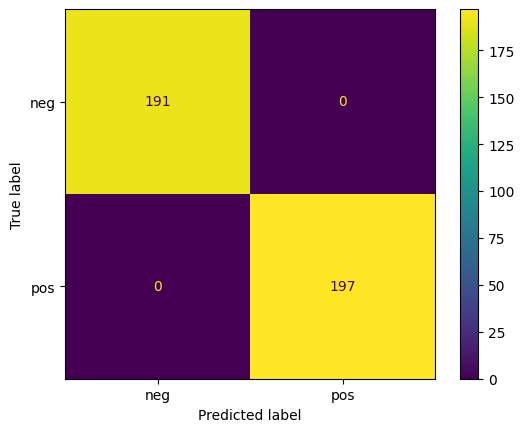

In [75]:
ConfusionMatrixDisplay.from_estimator(pipe,X_test,y_test)